Analyse Descriptive Univariée (Graphiques Utiles pour Rapport Finale)

In [25]:
import pandas as pd
df = pd.read_excel("Base_ER_FR.xlsx")

VARIABLE ID : identifiant unique associe a chaque observation

VARIABLE AGE_CLI : age du client

In [6]:
df["AGE_CLI"].describe(percentiles=[0.25, 0.5, 0.75])

count    99524.000000
mean        51.958472
std         14.941231
min         18.000000
25%         40.000000
50%         52.000000
75%         64.000000
max         92.000000
Name: AGE_CLI, dtype: float64

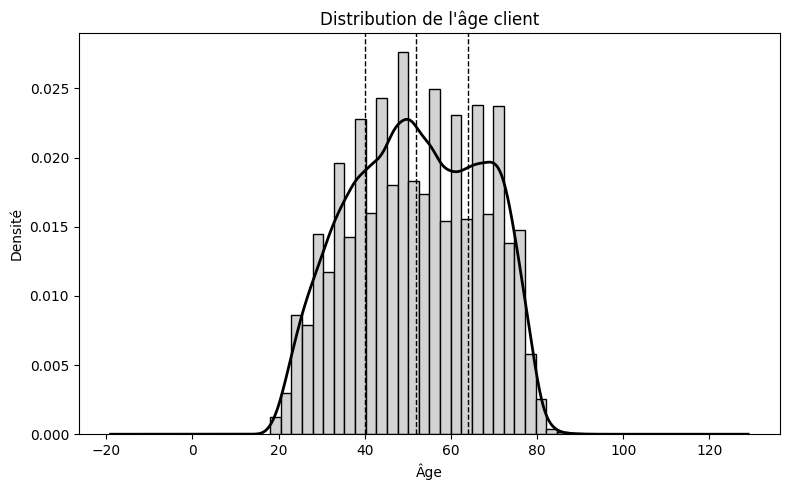

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

age = df["AGE_CLI"].dropna()

# quartiles
q25, q50, q75 = np.percentile(age, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(age, bins=30, density=True, color="lightgrey", edgecolor="black")

age.plot(kind="density", color="black", linewidth=2)
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de l'âge client")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()


In [ ]:
print(
    f"L'âge des clients est compris entre {int(age.min())} et {int(age.max())} ans. "
    f"La distribution est centrée autour de {int(q50)} ans, avec des premier et "
    f"troisième quartiles respectivement égaux à {int(q25)} et {int(q75)} ans. "
)


L'âge des clients est compris entre 18 et 92 ans. La distribution est centrée autour de 52 ans, avec des premier et troisième quartiles respectivement égaux à 40 et 64 ans. 


VARIABLE B_MAT : maturite initiale du credit, exprimee en mois

In [7]:
df["B_MAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    98620.000000
mean        70.807585
std         43.506068
min          0.000000
25%         48.000000
50%         61.000000
75%         78.250000
max        300.000000
Name: B_MAT, dtype: float64

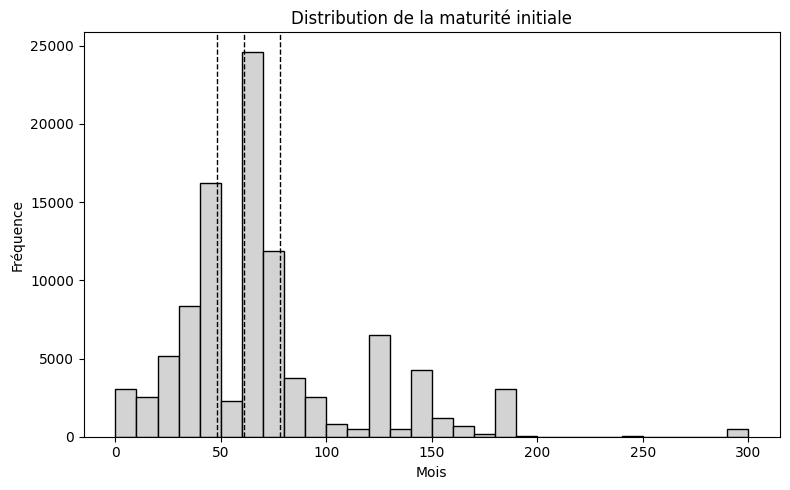

In [8]:
bmat = df["B_MAT"].dropna()
q25, q50, q75 = np.percentile(bmat, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(bmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité initiale")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

VARIABLE B_RESMAT : maturite residuelle du credit (duree restante jusqu’a l’echeance d’un
credit), exprimee en mois

In [10]:
df["B_RESMAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    98620.000000
mean        36.449990
std         37.721117
min          0.000000
25%          7.000000
50%         27.000000
75%         50.000000
max        298.000000
Name: B_RESMAT, dtype: float64

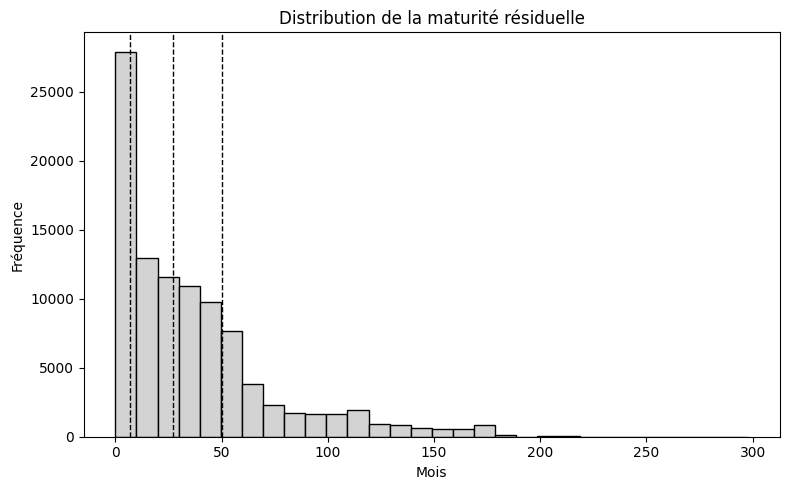

In [11]:
bresmat = df["B_RESMAT"].dropna()
q25, q50, q75 = np.percentile(bresmat, [25, 50, 75])

plt.figure(figsize=(8, 5))
plt.hist(bresmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité résiduelle")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

VARIABLE CLASSACT : classe d'actif

VARIABLE CSP : catégorie socio profesionnel (regroupement à traiter)

VARIABLE DARRET : date d’arret ou de reference associee au credit.

In [26]:
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(int).astype(str),
    format="%Y%m"
)

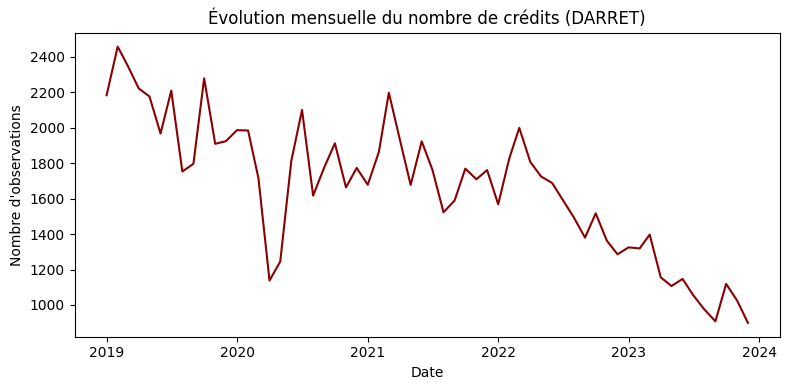

In [27]:
df["DARRET_M"] = df["DARRET"].dt.to_period("M").dt.to_timestamp()

monthly_counts = (
    df.groupby("DARRET_M")
    .size()
    .reset_index(name="n_obs")
)

plt.figure(figsize=(8, 4))
plt.plot(
    monthly_counts["DARRET_M"],
    monthly_counts["n_obs"],
    color="darkred",
    linewidth=1.5
)
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.title("Évolution mensuelle du nombre de crédits (DARRET)")
plt.tight_layout()
plt.show()

VARIABLE E_EAD :  exposition au defaut du contrat 

In [28]:
df["E_EAD"].describe(percentiles=[0.25, 0.5, 0.75])

count     98620.000000
mean        998.009810
std        5744.202071
min           0.000000
25%           0.000000
50%           0.000000
75%           0.190000
max      267563.810000
Name: E_EAD, dtype: float64

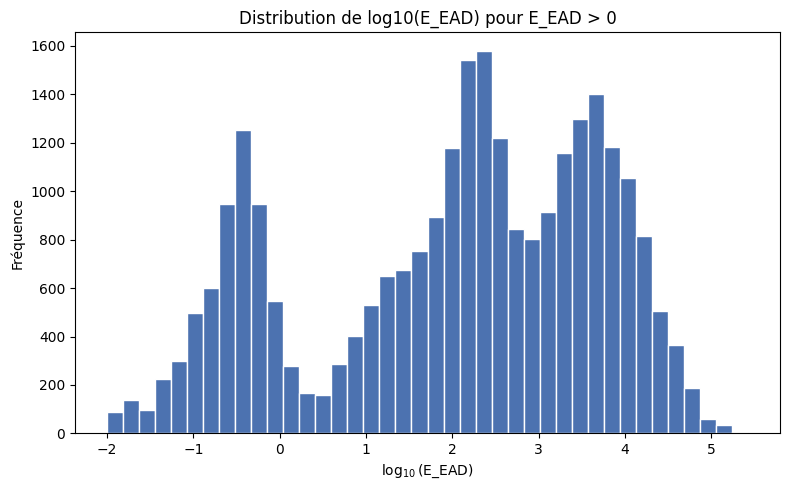

In [30]:
ead1 = df.loc[df["E_EAD"] > 0, "E_EAD"]
logead1 = np.log10(ead1)

plt.figure(figsize=(8, 5))
plt.hist(
    logead1,
    bins=40,
    color="#4C72B0",
    edgecolor="white"
)

plt.xlabel(r"$\log_{10}(\mathrm{E\_EAD})$")
plt.ylabel("Fréquence")
plt.title("Distribution de log10(E_EAD) pour E_EAD > 0")


plt.tight_layout()
plt.show()

VARIABLE E_OFF : exposition hors bilan associee au credit

In [31]:
df["E_OFF"].describe()

count    98620.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: E_OFF, dtype: float64

VARIABLE E_ONB : montant du bilan

In [33]:
(df["E_ONB"].fillna(0) == df["E_EAD"].fillna(0)).all()


np.True_

VARIABLE MREVAU : montant autre revenu client

In [34]:
df["MREVAU"].describe(percentiles=[0.25, 0.5, 0.75])

count     99954.00000
mean         96.15121
std         952.11043
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max      194096.00000
Name: MREVAU, dtype: float64

VARIABLE MREVNU : montant du revenu du client

In [35]:
df["MREVNU"].describe(percentiles=[0.25, 0.5, 0.75])

count     99954.000000
mean       2433.213588
std        2802.421818
min           0.000000
25%        1525.250000
50%        2000.000000
75%        2757.000000
max      265000.000000
Name: MREVNU, dtype: float64

VARIABLE MREVTOT :  montant du revenu total du client

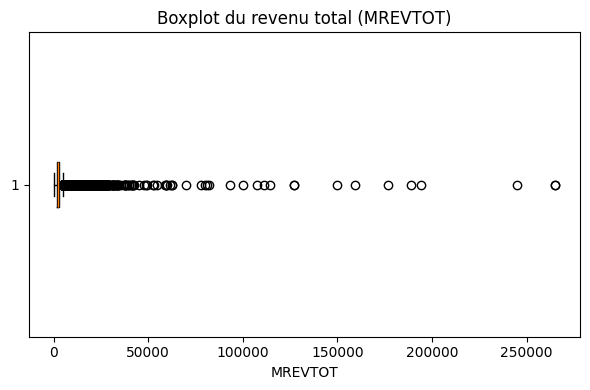

In [36]:
mrevtot = df["MREVTOT"].dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(
    mrevtot,
    vert=False,
    showfliers=True
)
plt.xlabel("MREVTOT")
plt.title("Boxplot du revenu total (MREVTOT)")

plt.tight_layout()
plt.show()

VARIABLE MTECH : montant de l’echeance theorique du credit (le paiement periodique contractuel que le client est cense verser a chaque echeance (mensualite), hors evenement particulier)

In [37]:
df["MTECH"].describe(percentiles=[0.25, 0.5, 0.75])

count    100000.000000
mean        228.889002
std         259.948942
min           0.000000
25%          94.670000
50%         178.685000
75%         296.970000
max       35915.740000
Name: MTECH, dtype: float64

VARIABLE NBIMP :  nombre d’impayes observes sur le credit.

In [38]:
df["NBIMP"].describe(percentiles=[0.25, 0.5, 0.75])

count    100000.000000
mean          0.006100
std           0.125471
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: NBIMP, dtype: float64

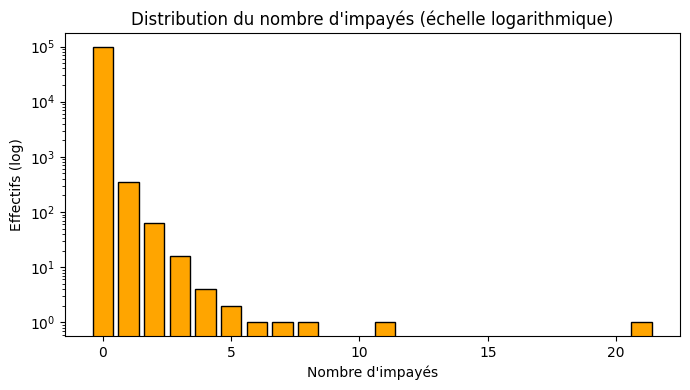

In [39]:
nbimp_counts = df["NBIMP"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(
    nbimp_counts.index,
    nbimp_counts.values,
    color="orange",
    edgecolor="black"
)

plt.yscale("log")
plt.xlabel("Nombre d'impayés")
plt.ylabel("Effectifs (log)")
plt.title("Distribution du nombre d'impayés (échelle logarithmique)")

plt.tight_layout()
plt.show()

VARIABLE NB_ECH : nombre total d’echeances prevues par le contrat.

In [40]:
df["NB_ECH"].describe(percentiles=[0.25, 0.5, 0.75])  

count    100000.000000
mean         62.102200
std          40.731397
min           1.000000
25%          36.000000
50%          60.000000
75%          72.000000
max         300.000000
Name: NB_ECH, dtype: float64

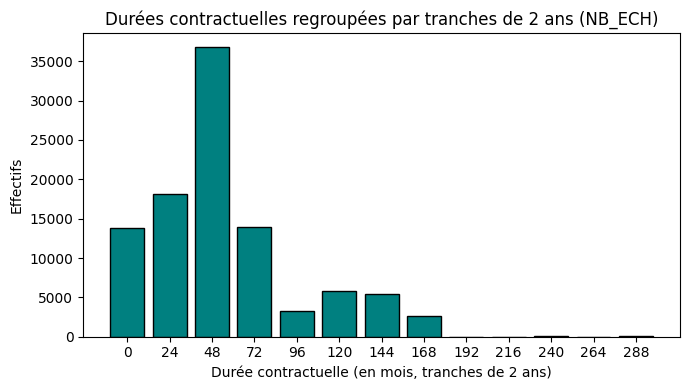

In [48]:
# Création de classes de 2 ans (24 mois)
df["NB_ECH_2Y"] = (df["NB_ECH"] // 24) * 24

nb_ech_2y_counts = (
    df["NB_ECH_2Y"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    nb_ech_2y_counts.index.astype(str),
    nb_ech_2y_counts.values,
    color="teal",
    edgecolor="black"
)

plt.xlabel("Durée contractuelle (en mois, tranches de 2 ans)")
plt.ylabel("Effectifs")
plt.title("Durées contractuelles regroupées par tranches de 2 ans (NB_ECH)")

plt.tight_layout()
plt.show()

VARIABLE produit :  type de produit de credit

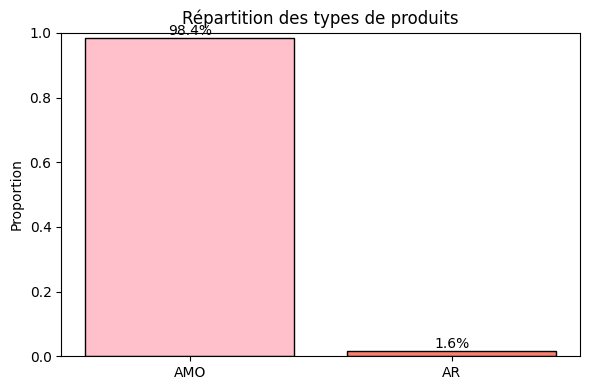

In [42]:
prod_counts = df["produit"].value_counts()
prod_props = prod_counts / prod_counts.sum()


plt.figure(figsize=(6, 4))
bars = plt.bar(
    prod_props.index,
    prod_props.values,
    color=["pink", "salmon"],
    edgecolor="black"
)

plt.ylabel("Proportion")
plt.title("Répartition des types de produits")

for bar, val in zip(bars, prod_props.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val*100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


VARIABLE RA :  montant du remboursement anticipe observe sur le credit

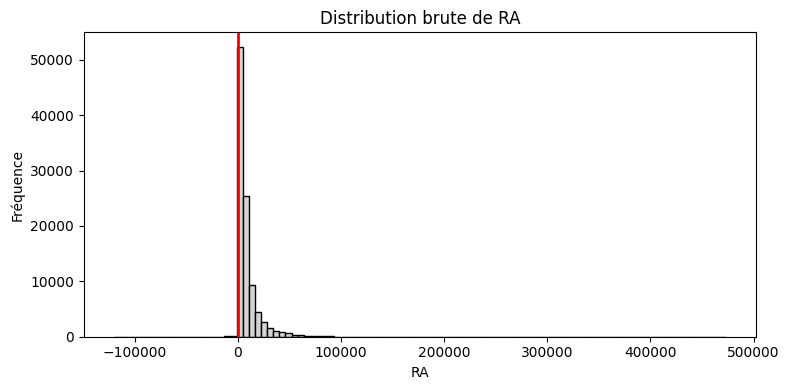

In [49]:
ra = df["RA"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    ra,
    bins=100,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("RA")
plt.ylabel("Fréquence")
plt.title("Distribution brute de RA")

plt.tight_layout()
plt.show()

VARIABLE Tx :  correspond au taux d’interet contractuel du credit

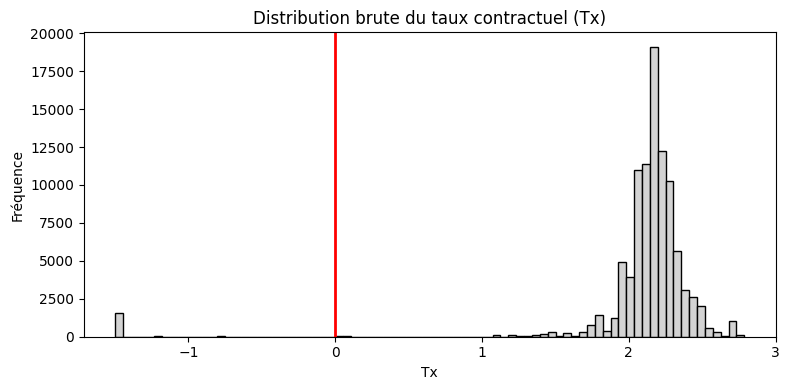

In [50]:
tx = df["Tx"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    tx,
    bins=80,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro (taux négatifs)
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution brute du taux contractuel (Tx)")

plt.tight_layout()
plt.show()

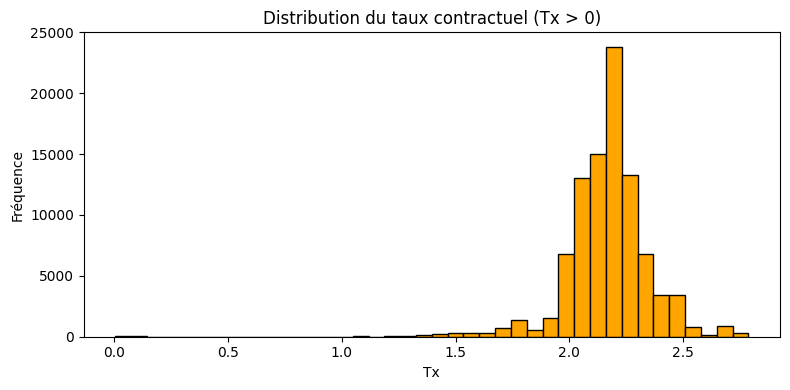

In [51]:
# Restriction aux taux strictement positifs
tx_pos = tx[tx > 0]

plt.figure(figsize=(8, 4))

plt.hist(
    tx_pos,
    bins=40,
    color="orange",
    edgecolor="black"
)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution du taux contractuel (Tx > 0)")

plt.tight_layout()
plt.show()
